# Scratch with Gradient Descent
Lets do now LinearRegression with gradient descent so that then  we compare it with sklearn's implementation

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class LinearRegressionGD:
    def __init__(self, eta=0.01, n_iterations=1000):
        self.eta = eta
        self.n_iterations = n_iterations
        self.theta = None
        self.intercept_ = None
        self.coef_ = None
        self.mse_history = []

    def fit(self, X, y):
        m = len(X)

        X_b = np.c_[np.ones((m, 1)), X] # adding bias

        np.random.seed(42) # for reproducibility
        self.theta = np.random.rand(X_b.shape[1], 1) # random initialization of weights

        for iteration in range(self.n_iterations):
            y_pred = X_b @ self.theta
            error = y_pred - y

            # saving mse to history
            self.mse_history.append(np.mean(error**2))


            gradient = 2/m * X_b.T @ error
            self.theta -= self.eta * gradient

        self.intercept_ = self.theta[0][0]
        self.coef_ = self.theta[1:].ravel()

        return self

    def predict(self, X):
        m = len(X)
        X_b = np.c_[np.ones((m, 1)), X] # adding bias   
        return X_b @ self.theta
    



if __name__ == "__main__":
    np.random.seed(42)
    X_data = np.random.rand(100, 1)*2
    y_data = 4 + X_data*3 + 0.5*np.random.randn(100, 1)

    # scratch implementing
    scratch_model = LinearRegressionGD(eta=0.1, n_iterations=1000)
    scratch_model.fit(X_data, y_data)
    print("---Scratch Implementation---")
    print(f"Intercept: {scratch_model.intercept_:.6f}")
    print(f"Coefficients: {scratch_model.coef_}")

    # sklearn implementation
    from sklearn.linear_model import SGDRegressor
    sklearn_model = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.1, learning_rate='constant', random_state=42)
    sklearn_model.fit(X_data, y_data.ravel())
    print("\n---Sklearn Implementation---")
    print(f"Intercept: {sklearn_model.intercept_[0]:.6f}")
    print(f"Coefficients: {sklearn_model.coef_[0]}")

    




---Scratch Implementation---
Intercept: 4.107548
Coefficients: [2.88505669]

---Sklearn Implementation---
Intercept: 4.061178
Coefficients: 2.84245021442154


Scratch Implementation - Batch Gradient Descent:
Intercept: 4.107548
Coefficients: 2.885057

Scikit-learn Implementation - SGDRegressor:
Intercept: 4.060438
Coefficients: 2.843189


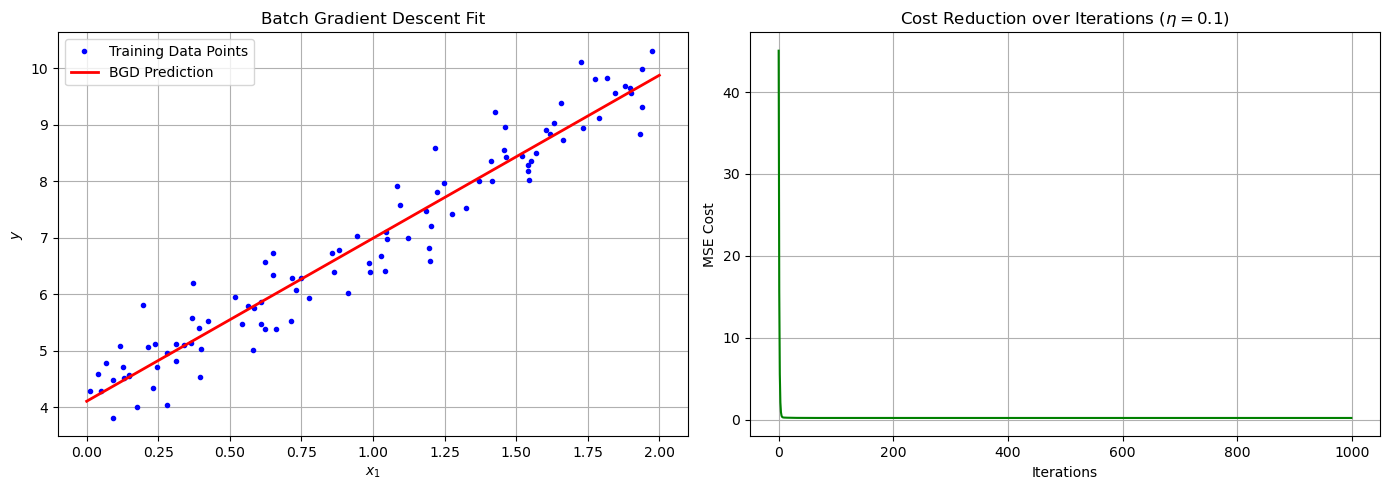

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler


class LinearRegressionGD:
    def __init__(self, eta=0.01, n_iterations=1000):
        self.eta = eta
        self.n_iterations = n_iterations
        self.theta = None
        self.intercept_ = None
        self.coef_ = None
        self.cost_history = []

    def fit(self, X, y):
        m = len(X)
        X_b = np.c_[np.ones((m, 1)), X] # adding bias 

        np.random.seed(42)
        self.theta = np.random.randn(X_b.shape[1], 1) # random weights initialization

        for iteration in range(self.n_iterations):
            # calculate error
            error = X_b @ self.theta - y

            # compute cost for current iteration
            cost = np.mean(error ** 2)
            self.cost_history.append(cost)

            # compute gradients
            gradients = (2 / m) * X_b.T @ error

            # updating weights
            self.theta -= self.eta * gradients

        self.intercept_ = self.theta[0]
        self.coef_ = self.theta[1:].ravel()
    
        return self

    def predict(self, X):
        m = len(X)
        X_b = np.c_[np.ones((m, 1)), X] # adding bias
        return X_b @ self.theta


if __name__ == "__main__":
    np.random.seed(42)
    X_data = 2 * np.random.rand(100, 1)
    y_data = 4 + 3 * X_data + np.random.randn(100, 1) * 0.5

    # Scratch implementation
    model_scratch = LinearRegressionGD(eta=0.1, n_iterations=1000)
    model_scratch.fit(X_data, y_data)
    print("Scratch Implementation - Batch Gradient Descent:")
    print(f"Intercept: {model_scratch.intercept_[0]:.6f}")
    print(f"Coefficients: {model_scratch.coef_[0]:.6f}")

    # Scikit-learn implementation
    # Note: SGDRegressor uses Stochastic GD (1 instance at a time), so parameters may vary slightly
    model_sklearn = SGDRegressor(max_iter=1000, eta0=0.1, learning_rate='constant', penalty=None, random_state=42)
    model_sklearn.fit(X_data, y_data.ravel())
    print("\nScikit-learn Implementation - SGDRegressor:")
    print(f"Intercept: {model_sklearn.intercept_[0]:.6f}")
    print(f"Coefficients: {model_sklearn.coef_[0]:.6f}")

    # 3. Plot predictions & cost reduction over iterations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot line fit
    X_new = np.array([[0], [2]])
    y_pred = model_scratch.predict(X_new)

    ax1.plot(X_data, y_data, "b.", label="Training Data Points")
    ax1.plot(X_new, y_pred, "r-", linewidth=2, label="BGD Prediction")
    ax1.set_xlabel("$x_1$")
    ax1.set_ylabel("$y$")
    ax1.set_title("Batch Gradient Descent Fit")
    ax1.legend()
    ax1.grid(True)

    # Plot Cost History
    ax2.plot(range(model_scratch.n_iterations), model_scratch.cost_history, "g-")
    ax2.set_xlabel("Iterations")
    ax2.set_ylabel("MSE Cost")
    ax2.set_title("Cost Reduction over Iterations ($\eta = 0.1$)")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()